# Credit Card Fraud Detection — EDA & Preprocessing

## 1. Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## 2. Load Dataset

In [2]:
df = pd.read_csv('../data/creditcard.csv')
df.head()

,Time,V1,V2,V3,V4,V5,V6,V7,V8,V9,...,V21,V22,V23,V24,V25,V26,V27,V28,Amount,Class
0,0.0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,...,-0.018307,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,149.62,0
1,0.0,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,...,-0.225775,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,2.69,0
2,1.0,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,...,0.247998,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,378.66,0
3,1.0,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,...,-0.108300,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,123.50,0
4,2.0,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,...,-0.009431,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,69.99,0


## 3. Data Inspection

In [3]:
df.shape

(284807, 31)

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 284807 entries, 0 to 284806
Data columns (total 31 columns):
 #   Column  Non-Null Count   Dtype  
---  ------  --------------   -----  
 0   Time    284807 non-null  float64
 1   V1      284807 non-null  float64
 2   V2      284807 non-null  float64
 3   V3      284807 non-null  float64
 4   V4      284807 non-null  float64
 5   V5      284807 non-null  float64
 6   V6      284807 non-null  float64
 7   V7      284807 non-null  float64
 8   V8      284807 non-null  float64
 9   V9      284807 non-null  float64
 10  V10     284807 non-null  float64
 11  V11     284807 non-null  float64
 12  V12     284807 non-null  float64
 13  V13     284807 non-null  float64
 14  V14     284807 non-null  float64
 15  V15     284807 non-null  float64
 16  V16     284807 non-null  float64
 17  V17     284807 non-null  float64
 18  V18     284807 non-null  float64
 19  V19     284807 non-null  float64
 20  V20     284807 non-null  float64
 21  V21     284807 non-nu

## 4. Missing Value Check

In [5]:
df.isnull().sum().sum()

np.int64(0)

In [6]:
df['Class'].value_counts()

Class
0    284315
1       492
Name: count, dtype: int64

In [7]:
df['Class'].value_counts(normalize=True) * 100

Class
0    99.827251
1     0.172749
Name: proportion, dtype: float64

## 5. Exploratory Data Analysis (EDA)

### 5.1 Class Distribution (Imbalance Check)

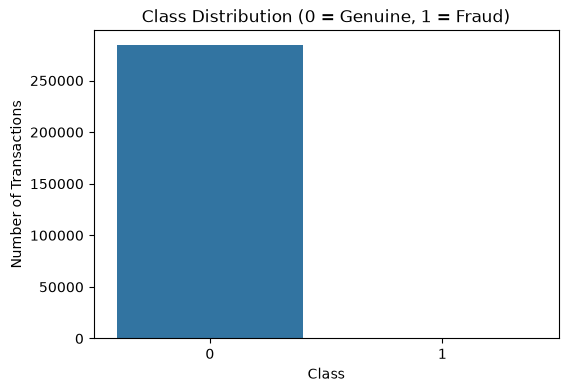

In [8]:
plt.figure(figsize=(6,4))
sns.countplot(x='Class', data=df)
plt.title('Class Distribution (0 = Genuine, 1 = Fraud)')
plt.xlabel('Class')
plt.ylabel('Number of Transactions')
plt.show()


### 5.2 Transaction Amount by Class

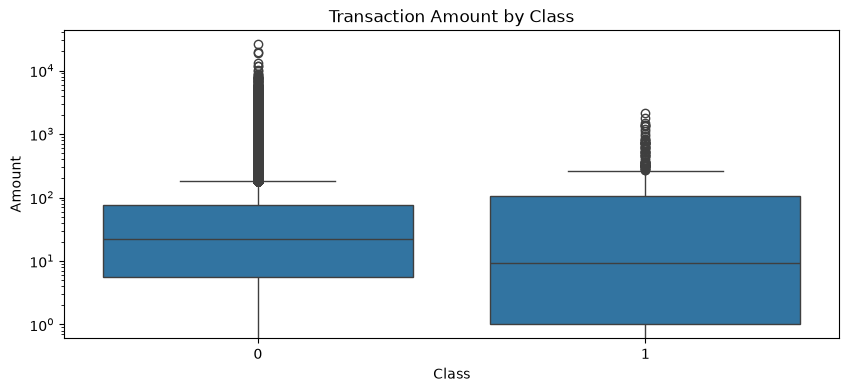

In [9]:
plt.figure(figsize=(10,4))
sns.boxplot(x='Class', y='Amount', data=df)
plt.title('Transaction Amount by Class')
plt.yscale('log')
plt.show()

### 5.3 Correlation Heatmap

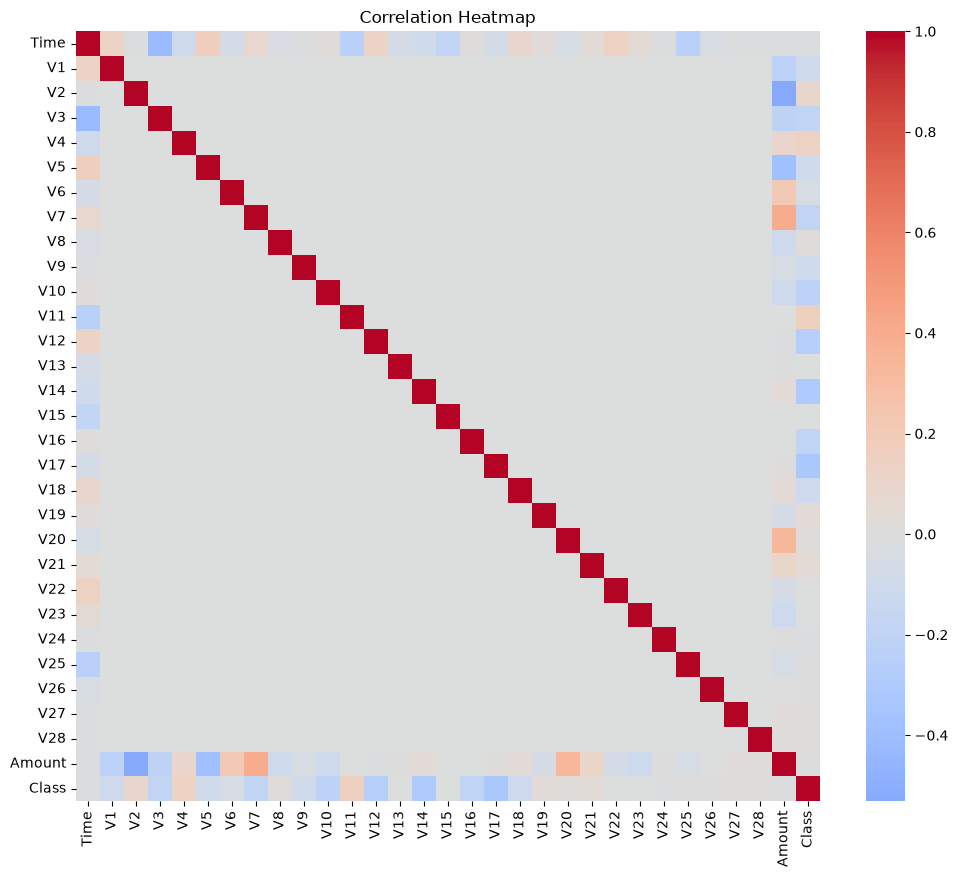

In [10]:
plt.figure(figsize=(12,10))
sns.heatmap(df.corr(), cmap='coolwarm', center=0)
plt.title('Correlation Heatmap')
plt.show()

In [11]:
df.corr()['Class'].sort_values(ascending=False)

Class     1.000000
V11       0.154876
V4        0.133447
V2        0.091289
V21       0.040413
V19       0.034783
V20       0.020090
V8        0.019875
V27       0.017580
V28       0.009536
Amount    0.005632
V26       0.004455
V25       0.003308
V22       0.000805
V23      -0.002685
V15      -0.004223
V13      -0.004570
V24      -0.007221
Time     -0.012323
V6       -0.043643
V5       -0.094974
V9       -0.097733
V1       -0.101347
V18      -0.111485
V7       -0.187257
V3       -0.192961
V16      -0.196539
V10      -0.216883
V12      -0.260593
V14      -0.302544
V17      -0.326481
Name: Class, dtype: float64

### 5.4 Feature Correlation with Fraud (Class)

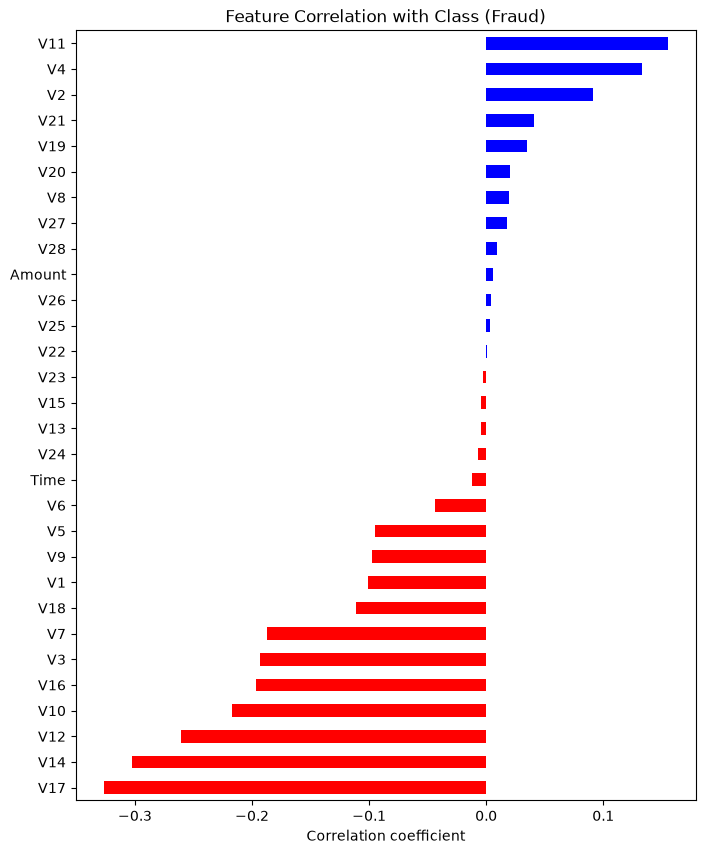

In [12]:
corr = df.corr()['Class'].drop('Class').sort_values()

plt.figure(figsize=(8,10))
corr.plot(kind='barh', color=['red' if v < 0 else 'blue' for v in corr])
plt.title('Feature Correlation with Class (Fraud)')
plt.xlabel('Correlation coefficient')
plt.show()

### 5.5 Transaction Time Distribution by Class

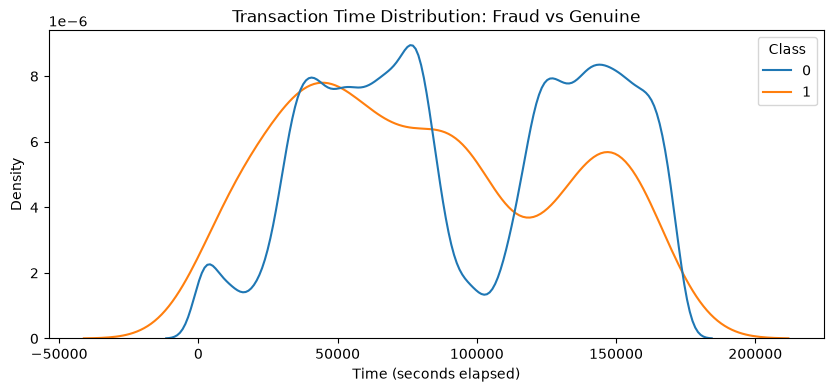

In [13]:
plt.figure(figsize=(10,4))
sns.kdeplot(data=df, x='Time', hue='Class', common_norm=False)
plt.title('Transaction Time Distribution: Fraud vs Genuine')
plt.xlabel('Time (seconds elapsed)')
plt.show()

## 6. Feature Scaling
Standardizing `Amount` and `Time` since all other features are already PCA-scaled.

In [14]:
from sklearn.preprocessing import StandardScaler
import joblib

amount_scaler = StandardScaler()
time_scaler = StandardScaler()

df['scaled_amount'] = amount_scaler.fit_transform(df[['Amount']])
df['scaled_time'] = time_scaler.fit_transform(df[['Time']])

df = df.drop(['Amount', 'Time'], axis=1)

joblib.dump(amount_scaler, '../models/amount_scaler.pkl')
joblib.dump(time_scaler, '../models/time_scaler.pkl')

df.head()

,V1,V2,V3,V4,V5,V6,V7,V8,V9,V10,...,V22,V23,V24,V25,V26,V27,V28,Class,scaled_amount,scaled_time
0,-1.359807,-0.072781,2.536347,1.378155,-0.338321,0.462388,0.239599,0.098698,0.363787,0.090794,...,0.277838,-0.110474,0.066928,0.128539,-0.189115,0.133558,-0.021053,0,0.244964,-1.996583
1,1.191857,0.266151,0.166480,0.448154,0.060018,-0.082361,-0.078803,0.085102,-0.255425,-0.166974,...,-0.638672,0.101288,-0.339846,0.167170,0.125895,-0.008983,0.014724,0,-0.342475,-1.996583
2,-1.358354,-1.340163,1.773209,0.379780,-0.503198,1.800499,0.791461,0.247676,-1.514654,0.207643,...,0.771679,0.909412,-0.689281,-0.327642,-0.139097,-0.055353,-0.059752,0,1.160686,-1.996562
3,-0.966272,-0.185226,1.792993,-0.863291,-0.010309,1.247203,0.237609,0.377436,-1.387024,-0.054952,...,0.005274,-0.190321,-1.175575,0.647376,-0.221929,0.062723,0.061458,0,0.140534,-1.996562
4,-1.158233,0.877737,1.548718,0.403034,-0.407193,0.095921,0.592941,-0.270533,0.817739,0.753074,...,0.798278,-0.137458,0.141267,-0.206010,0.502292,0.219422,0.215153,0,-0.073403,-1.996541


## 7. Train-Test Split
Using stratified split to preserve the fraud ratio in both sets.

In [15]:
from sklearn.model_selection import train_test_split

X = df.drop('Class', axis=1)
y = df['Class']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, stratify=y, random_state=42
)

print(X_train.shape, X_test.shape)
print(y_train.value_counts())
print(y_test.value_counts())

(227845, 30) (56962, 30)
Class
0    227451
1       394
Name: count, dtype: int64
Class
0    56864
1       98
Name: count, dtype: int64


## 8. Handling Class Imbalance (SMOTE)
Applying SMOTE only on training data to avoid data leakage.

In [16]:
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state=42)
X_train_smote, y_train_smote = smote.fit_resample(X_train, y_train)

print(y_train_smote.value_counts())

Class
0    227451
1    227451
Name: count, dtype: int64


### 8.1 Before vs After SMOTE Comparison

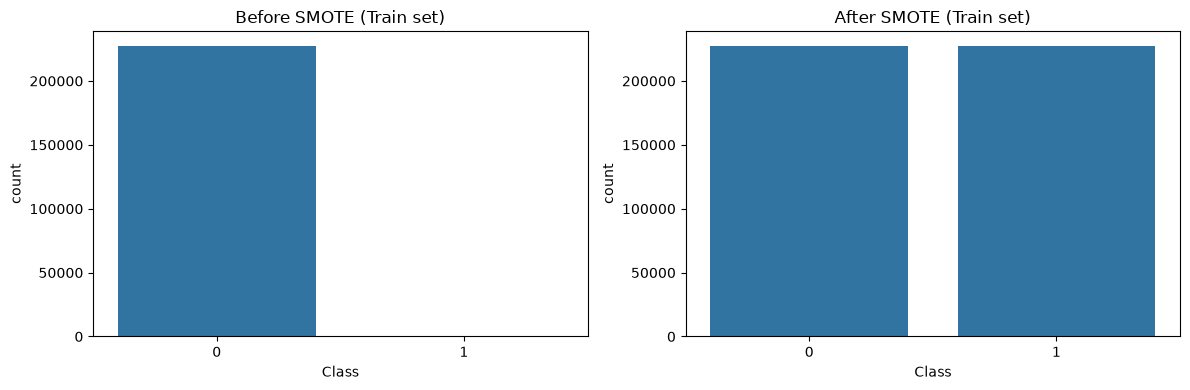

In [17]:
fig, axes = plt.subplots(1, 2, figsize=(12,4))

sns.countplot(x=y_train, ax=axes[0])
axes[0].set_title('Before SMOTE (Train set)')

sns.countplot(x=y_train_smote, ax=axes[1])
axes[1].set_title('After SMOTE (Train set)')

plt.tight_layout()
plt.show()

### 8.2 Visualizing Synthetic Samples (V14 vs V17)

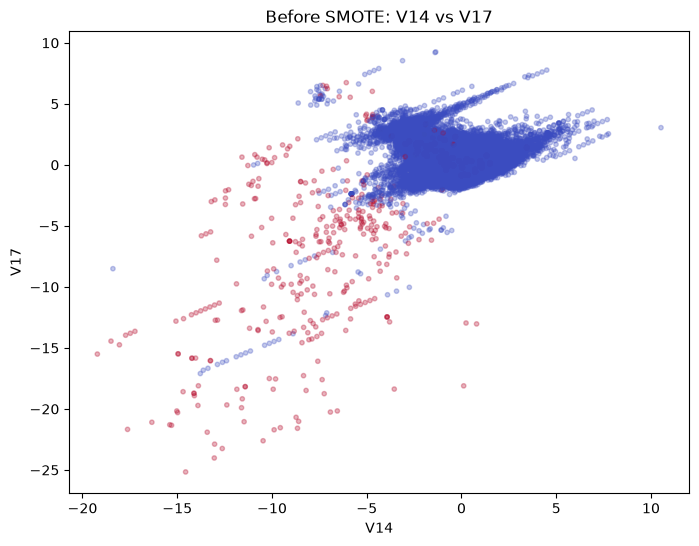

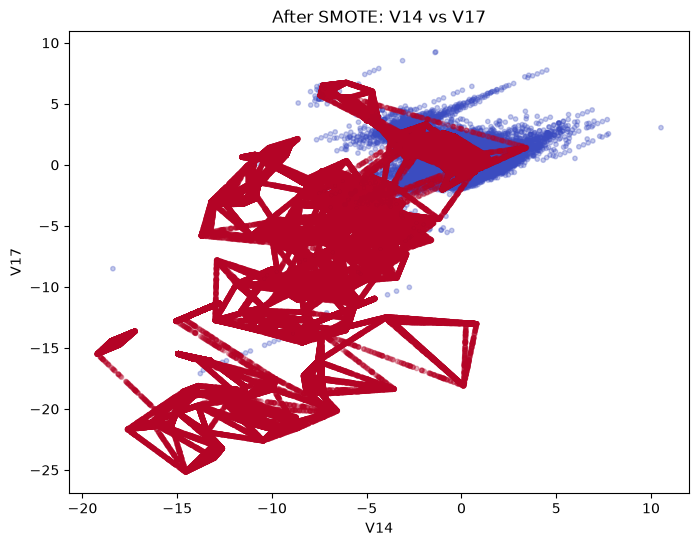

In [18]:
plt.figure(figsize=(8,6))
plt.scatter(X_train['V14'], X_train['V17'], c=y_train, cmap='coolwarm', alpha=0.3, s=10, label='Original')
plt.title('Before SMOTE: V14 vs V17')
plt.xlabel('V14')
plt.ylabel('V17')
plt.show()

plt.figure(figsize=(8,6))
plt.scatter(X_train_smote['V14'], X_train_smote['V17'], c=y_train_smote, cmap='coolwarm', alpha=0.3, s=10, label='SMOTE')
plt.title('After SMOTE: V14 vs V17')
plt.xlabel('V14')
plt.ylabel('V17')
plt.show()

## 9. Save Processed Data
Saving train/test splits (original and SMOTE-balanced) for use in the model training notebook.

In [19]:
import joblib

joblib.dump((X_train, X_test, y_train, y_test, X_train_smote, y_train_smote), '../data/processed_data.pkl')

['../data/processed_data.pkl']